[![Wiki](https://img.shields.io/badge/-Wiki-blue?style=flat-square&logo=github)](./wiki/05-Effect-of-W-D-C-Variants.md)
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/neurovium/CorticalBlueprintRNN/blob/main/StatisticalAnalysis/The_Effect_of_w%2C_d_and_c_variants_Task_2.ipynb)

*Effect of W, D, C variants — Task 2 (Supplementary Tables S5–S7, Task 2 column). See [wiki 05 — Effect of W, D, C](./wiki/05-Effect-of-W-D-C-Variants.md).*

# Import Libraries

In [ ]:
import os
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kruskal
from scipy.stats import mannwhitneyu
import itertools
import seaborn as sns
from scipy import stats
from scipy.stats import friedmanchisquare
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import itertools
from statsmodels.stats.multitest import multipletests

# Load dataset

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/ISP

Papers	simu.zip


In [ ]:
!unzip /content/drive/MyDrive/ISP/simu.zip -d /content/data

Archive:  /content/drive/MyDrive/ISP/simu.zip
   creating: /content/data/simu/
   creating: /content/data/simu/5_6_8_sttc-precision_sign+/
  inflating: /content/data/__MACOSX/simu/._5_6_8_sttc-precision_sign+  
  inflating: /content/data/simu/.DS_Store  
  inflating: /content/data/__MACOSX/simu/._.DS_Store  
   creating: /content/data/simu/5_6_8_sttc-corr_sign+/
  inflating: /content/data/__MACOSX/simu/._5_6_8_sttc-corr_sign+  
   creating: /content/data/simu/5_3_4_sttc-corr/
  inflating: /content/data/__MACOSX/simu/._5_3_4_sttc-corr  
   creating: /content/data/simu/5_3_4_sttc-corr_sign+/
  inflating: /content/data/__MACOSX/simu/._5_3_4_sttc-corr_sign+  
   creating: /content/data/simu/5_3_4_sttc-precision_sign+/
  inflating: /content/data/__MACOSX/simu/._5_3_4_sttc-precision_sign+  
   creating: /content/data/simu/6_6_2_sttc-precision_sign+/
  inflating: /content/data/__MACOSX/simu/._6_6_2_sttc-precision_sign+  
   creating: /content/data/simu/6_6_2_sttc-precision/
  inflating: /cont

In [ ]:
print(os.listdir("/content/data/simu"))

['5_6_8_sttc-precision', 'rcc.ipynb', '6_6_2_sttc-precision', '5_6_8_sttc-precision_sign+', 'plotting.ipynb', '6_6_2_sttc-corr_sign+', '5_3_4_sttc-precision_sign+', '6_6_2_sttc-corr', '6_6_2_sttc-precision_sign+', '.DS_Store', '5_3_4_sttc-corr_sign+', '5_6_8_sttc-corr', '5_6_8_sttc-corr_sign+', '5_3_4_sttc-corr', '5_3_4_sttc-precision']


## In the same scan and field

In [ ]:
session, scan, field = 6, 6, 2

sign_constraint = False # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = False # Whether to use the precision matrix for the bio weights

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name = f'/content/data/simu/{base}'
print(folder_name)

# task1_file_dir = f'{folder_name}/Task1/{metric}_raw.csv'
# task2_file_dir = f'{folder_name}/Task2/{metric}_raw.csv'
# task3_file_dir = f'{folder_name}/Task3/{metric}_raw.csv'

/content/data/simu/6_6_2_sttc-corr


In [ ]:
task1_folder_dir = f'{folder_name}/Task2/'

In [ ]:
import pandas as pd

# List your metric files and their corresponding column names
metrics_dic = {
    "Accuracy_raw.csv": "accuracy",
    "Assortativity_raw.csv": "assortivity",
    "Modularity_raw.csv": "modularity",
    "Entropy_raw.csv": "entropy",
    "SmallWorldness_raw.csv": "smallWorldness",
    "Loss_raw.csv" : "loss",
    "Validation_Accuracy_raw.csv" : "validation_accuracy",
    "Validation_Loss_raw.csv" : "validation_loss"
}

dfs = []

for file, metric_name in metrics_dic.items():
    file_path = os.path.join(task1_folder_dir, file)
    # Read CSV (first column is simulation number / index)
    df = pd.read_csv(file_path, index_col=0)

    # Convert from wide format to long format
    df_long = df.reset_index().melt(
        id_vars=df.index.name,  # simulation number
        var_name="model_name",
        value_name=metric_name
    )

    dfs.append(df_long)

# Merge all metrics on simulation_number + model_name
from functools import reduce
final_df = reduce(lambda left, right: pd.merge(left, right, on=[df.index.name, "model_name"]), dfs)

# Rename index column to simulation_number
final_df.rename(columns={df.index.name: "simulation_number"}, inplace=True)

# Save to CSV
final_df.to_csv("combined_dataset.csv", index=False)



print(final_df.head())

   simulation_number model_name  accuracy  assortivity  modularity   entropy  \
0                  0      W*D*C  1.000000    -0.406047    0.484728  0.085580   
1                  1      W*D*C  0.942383    -0.102946    0.357961  2.206372   
2                  2      W*D*C  1.000000     0.074404    0.428333  0.262255   
3                  3      W*D*C  1.000000    -0.238329    0.275779  1.552414   
4                  4      W*D*C  0.511523     0.002365    0.211980  0.033078   

   smallWorldness      loss  validation_accuracy  validation_loss  
0        1.474579  0.005158             1.000000         0.004897  
1        1.922020  1.032156             1.000000         0.812350  
2        2.596384  0.014296             1.000000         0.013379  
3        2.589548  0.506123             1.000000         0.486825  
4        1.573246  0.693225             0.503125         0.693287  


In [ ]:
def classify_variant(model):
    if "W*" in model:
        return "w*"
    elif "W!" in model:
        return "w!"
    else:
        return "w"

final_df["w_variant"] = final_df["model_name"].apply(classify_variant)


In [ ]:
scaler = MinMaxScaler()
final_df["loss"] = scaler.fit_transform(final_df[["loss"]])
final_df['validation_loss'] = scaler.fit_transform(final_df[["validation_loss"]])


In [ ]:
final_df.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant
0,0,W*D*C,1.000000,-0.406047,0.484728,0.085580,1.474579,0.000099,1.000000,0.000086,w*
1,1,W*D*C,0.942383,-0.102946,0.357961,2.206372,1.922020,0.026456,1.000000,0.018781,w*
2,2,W*D*C,1.000000,0.074404,0.428333,0.262255,2.596384,0.000333,1.000000,0.000283,w*
3,3,W*D*C,1.000000,-0.238329,0.275779,1.552414,2.589548,0.012956,1.000000,0.011244,w*
4,4,W*D*C,0.511523,0.002365,0.211980,0.033078,1.573246,0.017757,0.503125,0.016025,w*


# Compare only two models

In [ ]:
metrics = ['accuracy', 'assortivity', 'entropy', 'loss', 'modularity', 'smallWorldness', 'validation_accuracy', 'validation_loss']

In [ ]:
def are_models_significantly_different(df, model1, model2, metric):
  res = kruskal(
    df.query(f"model_name == '{model1}'")[metric],
    df.query(f"model_name == '{model2}'")[metric],
  )

  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:
# are_models_significantly_different(final_df, 'WD*C*', 'W*D*C*', "smallWorldness")

for metric in metrics:
  print(f'{metric} : {are_models_significantly_different(final_df, 'WD*C*', 'W*D*C*', metric)}')

accuracy : (True, np.float64(8.45840531511352e-08))
assortivity : (True, np.float64(6.301848221392254e-08))
entropy : (False, np.float64(0.5699997477501239))
loss : (True, np.float64(1.5045973945099878e-05))
modularity : (False, np.float64(0.6456228047372135))
smallWorldness : (True, np.float64(6.301848221392254e-08))
validation_accuracy : (True, np.float64(1.6155926289380848e-08))
validation_loss : (True, np.float64(1.5045973945099878e-05))


In [ ]:
# are_models_significantly_different(final_df, 'W*D*C*', 'W!D*C*', "smallWorldness")

for metric in metrics:
  print(f'{metric} : {are_models_significantly_different(final_df, 'W*D*C*', 'W!D*C*', metric)}')

accuracy : (False, np.float64(0.9999998170078247))
assortivity : (False, np.float64(0.8710691939955872))
entropy : (False, np.float64(0.9138367624408422))
loss : (False, np.float64(0.9138367624408422))
modularity : (False, np.float64(0.34376459713412766))
smallWorldness : (False, np.float64(0.8286754110725028))
validation_accuracy : (False, np.float64(0.9999998170078247))
validation_loss : (False, np.float64(0.9568553503695676))


In [ ]:
# are_models_significantly_different(final_df, 'WD*C', 'W!D*C', "smallWorldness")

for metric in metrics:
  print(f'{metric} : {are_models_significantly_different(final_df, 'WD*C', 'W!D*C', metric)}')

accuracy : (False, np.float64(0.728443651478776))
assortivity : (True, np.float64(6.301848221392254e-08))
entropy : (True, np.float64(6.301848221392254e-08))
loss : (True, np.float64(9.882703709104151e-08))
modularity : (True, np.float64(0.03980114550533256))
smallWorldness : (True, np.float64(0.03046380272268875))
validation_accuracy : (False, np.float64(0.9585386339859624))
validation_loss : (True, np.float64(1.1465546070186638e-07))


# Compare the effect of w_variant

In [ ]:
def are_w_variants_significantly_different(df, metric):
  res = kruskal(
    df.query("w_variant == 'w'")[metric],
    df.query("w_variant == 'w*'")[metric],
    df.query("w_variant == 'w!'")[metric]
  )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue


In [ ]:
are_w_variants_significantly_different(final_df, "smallWorldness")

(True, np.float64(1.5611497575726752e-16))

In [ ]:
metrics = ['accuracy', 'assortivity', 'entropy', 'loss', 'modularity', 'smallWorldness', 'validation_accuracy', 'validation_loss']

for metric in metrics:
  print(f'{metric} : {are_w_variants_significantly_different(final_df, metric)}')

accuracy : (True, np.float64(1.9527264153682372e-24))
assortivity : (True, np.float64(4.902447237314223e-28))
entropy : (True, np.float64(5.5908995271425666e-05))
loss : (True, np.float64(0.0024122717441076203))
modularity : (True, np.float64(2.7639805407428878e-05))
smallWorldness : (True, np.float64(1.5611497575726752e-16))
validation_accuracy : (True, np.float64(1.6131321815368832e-26))
validation_loss : (True, np.float64(0.0024165026313094774))


In [ ]:
def how_w_variants_are_different(df, metric):
    groups = df["w_variant"].unique()
    pairs = list(itertools.combinations(groups, 2))

    print(f"\n------ {metric} ------")
    for g1, g2 in pairs:
        x = df.query("w_variant == @g1")[metric].dropna().astype(float)
        y = df.query("w_variant == @g2")[metric].dropna().astype(float)

        u, p = mannwhitneyu(x, y, alternative='two-sided')

        median_x, median_y = np.median(x), np.median(y)
        mean_x, mean_y = np.mean(x), np.mean(y)

        n1, n2 = len(x), len(y)
        prob_superiority = u / (n1 * n2)  # P(X > Y)

        direction = ">" if median_x > median_y else "<" if median_x < median_y else "="

        signif = "TRUE" if p < 0.05 else "FALSE"
        print(
            f"{g1} vs {g2}: {signif}, "
            f"U={u:.1f}, p={p:.3g}, "
            f"Median({g1})={median_x:.3f}, Median({g2})={median_y:.3f}, "
            f"Mean({g1})={mean_x:.3f}, Mean({g2})={mean_y:.3f}, "
            f"{g1} {direction} {g2}, P(X>Y)={prob_superiority:.2f}"
        )
    print("\n")


In [ ]:
for metric in metrics:
  how_w_variants_are_different(final_df, metric)


------ accuracy ------
w* vs w: TRUE, U=6287.5, p=1.2e-17, Median(w*)=1.000, Median(w)=0.512, Mean(w*)=0.942, Mean(w)=0.583, w* > w, P(X>Y)=0.87
w* vs w!: FALSE, U=1181.5, p=0.828, Median(w*)=1.000, Median(w!)=1.000, Mean(w*)=0.942, Mean(w!)=0.951, w* = w!, P(X>Y)=0.49
w vs w!: TRUE, U=497.5, p=5.5e-15, Median(w)=0.512, Median(w!)=1.000, Mean(w)=0.583, Mean(w!)=0.951, w < w!, P(X>Y)=0.10



------ assortivity ------
w* vs w: TRUE, U=535.0, p=1.42e-20, Median(w*)=-0.062, Median(w)=-0.001, Mean(w*)=-0.076, Mean(w)=0.089, w* < w, P(X>Y)=0.07
w* vs w!: FALSE, U=1442.0, p=0.0893, Median(w*)=-0.062, Median(w!)=-0.077, Mean(w*)=-0.076, Mean(w!)=-0.086, w* > w!, P(X>Y)=0.60
w vs w!: TRUE, U=4584.0, p=7.69e-18, Median(w)=-0.001, Median(w!)=-0.077, Mean(w)=0.089, Mean(w!)=-0.086, w > w!, P(X>Y)=0.95



------ entropy ------
w* vs w: TRUE, U=2238.0, p=3.6e-05, Median(w*)=0.030, Median(w)=0.509, Mean(w*)=0.296, Mean(w)=2.165, w* < w, P(X>Y)=0.31
w* vs w!: TRUE, U=870.0, p=0.0204, Median(w*)=0.030

# Effect of sign constraint on W

In [ ]:
session, scan, field = 6, 6, 2

sign_constraint = True # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = False # Whether to use the precision matrix for the bio weights

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name_1 = f'/content/data/simu/{base}'
print(folder_name_1)

/content/data/simu/6_6_2_sttc-corr_sign+


In [ ]:
task1_folder_dir_sign = f'{folder_name_1}/Task2/'
task1_folder_dir_sign

'/content/data/simu/6_6_2_sttc-corr_sign+/Task2/'

In [ ]:
import pandas as pd

# List your metric files and their corresponding column names
metrics_dic = {
    "Accuracy_raw.csv": "accuracy",
    "Assortativity_raw.csv": "assortivity",
    "Modularity_raw.csv": "modularity",
    "Entropy_raw.csv": "entropy",
    "SmallWorldness_raw.csv": "smallWorldness",
    "Loss_raw.csv" : "loss",
    "Validation_Accuracy_raw.csv" : "validation_accuracy",
    "Validation_Loss_raw.csv" : "validation_loss"
}

dfs = []

for file, metric_name in metrics_dic.items():
    file_path = os.path.join(task1_folder_dir_sign, file)
    # Read CSV (first column is simulation number / index)
    df = pd.read_csv(file_path, index_col=0)

    # Convert from wide format to long format
    df_long = df.reset_index().melt(
        id_vars=df.index.name,  # simulation number
        var_name="model_name",
        value_name=metric_name
    )

    dfs.append(df_long)

# Merge all metrics on simulation_number + model_name
from functools import reduce
final_df_sign = reduce(lambda left, right: pd.merge(left, right, on=[df.index.name, "model_name"]), dfs)

# Rename index column to simulation_number
final_df_sign.rename(columns={df.index.name: "simulation_number"}, inplace=True)

# Save to CSV
final_df_sign.to_csv("combined_dataset_1.csv", index=False)

print(final_df_sign.head())

   simulation_number model_name  accuracy  assortivity  modularity   entropy  \
0                  0      W*D*C       1.0    -0.038558    0.457619  0.096917   
1                  1      W*D*C       1.0    -0.032957    0.472359  0.164157   
2                  2      W*D*C       1.0    -0.320977    0.469744  0.119832   
3                  3      W*D*C       1.0    -0.214085    0.400230  0.077593   
4                  4      W*D*C       1.0    -0.210946    0.494909  0.153815   

   smallWorldness      loss  validation_accuracy  validation_loss  
0        1.505166  0.005311                  1.0         0.004977  
1        1.343280  0.007041                  1.0         0.006691  
2        1.989066  0.004715                  1.0         0.004418  
3        3.608053  0.003770                  1.0         0.003169  
4        3.565607  0.022458                  1.0         0.021465  


In [ ]:
scaler = MinMaxScaler()
final_df_sign["w_variant"] = final_df_sign["model_name"].apply(classify_variant)
final_df_sign["loss"] = scaler.fit_transform(final_df_sign[["loss"]])
final_df_sign['validation_loss'] = scaler.fit_transform(final_df_sign[["validation_loss"]])

In [ ]:
final_df_sign.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant
0,0,W*D*C,1.0,-0.038558,0.457619,0.096917,1.505166,0.000264,1.0,0.000249,w*
1,1,W*D*C,1.0,-0.032957,0.472359,0.164157,1.343280,0.000391,1.0,0.000375,w*
2,2,W*D*C,1.0,-0.320977,0.469744,0.119832,1.989066,0.000220,1.0,0.000208,w*
3,3,W*D*C,1.0,-0.214085,0.400230,0.077593,3.608053,0.000151,1.0,0.000117,w*
4,4,W*D*C,1.0,-0.210946,0.494909,0.153815,3.565607,0.001524,1.0,0.001461,w*


In [ ]:
non_biological_metrics = ['accuracy', 'loss', 'validation_accuracy', 'validation_loss']
biological_metrics = ['assortivity', 'entropy', 'modularity', 'smallWorldness']

In [ ]:
final_df['sign'] = False
final_df_sign['sign'] = True

In [ ]:
combined_df_sign = pd.concat([final_df, final_df_sign], ignore_index=True)

combined_df_sign = combined_df_sign.sort_values(["simulation_number", "model_name"]).reset_index(drop=True)

combined_df_sign.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant,sign
0,0,W,0.511133,-0.003897,0.089476,5.714332,0.980991,0.330465,0.503125,0.297299,w,False
1,0,W,0.498633,NaN,NaN,NaN,NaN,NaN,0.505469,NaN,w,True
2,0,W!D*C,1.000000,-0.015213,0.363863,1.526734,2.383137,0.000484,1.000000,0.000421,w!,False
3,0,W!D*C,1.000000,-0.154720,0.560428,0.125470,3.138540,0.002117,1.000000,0.002025,w!,True
4,0,W!D*C*,1.000000,-0.062564,0.086193,0.583860,0.995028,0.382233,1.000000,0.347821,w!,False


In [ ]:
combined_df_sign.shape

(440, 12)

In [ ]:
def is_sign_constraint_significantly_different(df, metric):
  res = kruskal(
    df.query("sign == True")[metric],
    df.query("sign == False")[metric]
    )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:
def how_sign_constraint_is_different(df, metric, variant):
  groups = df["sign"].unique()
  pairs = list(itertools.combinations(groups, 2))

  print(f"\n------ {metric}--- {variant} ------")
  for g1, g2 in pairs:
      x = df.query("sign == @g1")[metric].dropna().astype(float)
      y = df.query("sign == @g2")[metric].dropna().astype(float)

      u, p = mannwhitneyu(x, y, alternative='two-sided')

      median_x, median_y = np.median(x), np.median(y)
      mean_x, mean_y = np.mean(x), np.mean(y)

      n1, n2 = len(x), len(y)
      prob_superiority = u / (n1 * n2)  # P(X > Y)

      direction = ">" if median_x > median_y else "<" if median_x < median_y else "="

      signif = "TRUE" if p < 0.05 else "FALSE"
      print(
          f"{'sign constraint' if g1 else 'no sign'} vs {'sign constraint' if g2 else 'no sign'}: {signif}, "
          f"U={u:.1f}, p={p:.3g}, "
          f"Median({'sign constraint' if g1 else 'no sign'} )={median_x:.3f}, Median({'sign constraint' if g2 else 'no sign'})={median_y:.3f}, "
          f"Mean({'sign constraint' if g1 else 'no sign'} )={mean_x:.3f}, Mean({'sign constraint' if g2 else 'no sign'})={mean_y:.3f}, "
          f"{'sign constraint' if g1 else 'no sign'} {direction} {'sign constraint' if g2 else 'no sign'} , P(X>Y)={prob_superiority:.2f}"
      )
  print("\n")

In [ ]:
for metric in non_biological_metrics:
    print(f'W - {metric} : {is_sign_constraint_significantly_different(combined_df_sign[combined_df_sign['w_variant'] == 'w'], metric)}')
    print(f'W* - {metric} : {is_sign_constraint_significantly_different(combined_df_sign[combined_df_sign['w_variant'] == 'w*'], metric)}')
    print(f'W! - {metric} : {is_sign_constraint_significantly_different(combined_df_sign[combined_df_sign['w_variant'] == 'w!'], metric)}\n')

W - accuracy : (False, np.float64(nan))
W* - accuracy : (False, np.float64(nan))
W! - accuracy : (False, np.float64(nan))

W - loss : (False, np.float64(nan))
W* - loss : (False, np.float64(nan))
W! - loss : (False, np.float64(nan))

W - validation_accuracy : (False, np.float64(nan))
W* - validation_accuracy : (False, np.float64(nan))
W! - validation_accuracy : (False, np.float64(nan))

W - validation_loss : (False, np.float64(nan))
W* - validation_loss : (False, np.float64(nan))
W! - validation_loss : (False, np.float64(nan))



/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-in

In [ ]:
for metric in non_biological_metrics:
  how_sign_constraint_is_different(combined_df_sign[combined_df_sign['w_variant'] == 'w'], metric, 'w')
  how_sign_constraint_is_different(combined_df_sign[combined_df_sign['w_variant'] == 'w*'], metric, 'w*')
  how_sign_constraint_is_different(combined_df_sign[combined_df_sign['w_variant'] == 'w!'], metric, 'w!')


------ accuracy--- w ------


TypeError: unsupported object type: <class 'function'>

#### Biological Metrics

In [ ]:
for metric in biological_metrics:
  print(f'W* - {metric} : {is_sign_constraint_significantly_different(combined_df_sign[(combined_df_sign["w_variant"] == "w*")], metric)}')
  print(f'W! - {metric} : {is_sign_constraint_significantly_different(combined_df_sign[(combined_df_sign["w_variant"] == "w!")], metric)}')

W* - assortivity : (False, np.float64(nan))
W! - assortivity : (False, np.float64(nan))
W* - entropy : (False, np.float64(nan))
W! - entropy : (False, np.float64(nan))
W* - modularity : (False, np.float64(nan))
W! - modularity : (False, np.float64(nan))
W* - smallWorldness : (False, np.float64(nan))
W! - smallWorldness : (False, np.float64(nan))


/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-in

In [ ]:
for metric in biological_metrics:
  how_sign_constraint_is_different(combined_df_sign[combined_df_sign['w_variant'] == 'w*'], metric, 'w*')
  how_sign_constraint_is_different(combined_df_sign[combined_df_sign['w_variant'] == 'w!'], metric, 'w!')


------ assortivity--- w* ------


TypeError: unsupported object type: <class 'function'>

# Correlation matrix vs Presicion matrix effect on W




In [ ]:
session, scan, field = 6, 6, 2

sign_constraint = False # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = True # Whether to use the precision matrix for the bio weights

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name_2 = f'/content/data/simu/{base}'
print(folder_name_2)

/content/data/simu/6_6_2_sttc-precision


In [ ]:
task1_folder_dir_precision = f'{folder_name_2}/Task2/'
task1_folder_dir_precision

'/content/data/simu/6_6_2_sttc-precision/Task2/'

In [ ]:
import pandas as pd

# List your metric files and their corresponding column names
metrics_dic = {
    "Accuracy_raw.csv": "accuracy",
    "Assortativity_raw.csv": "assortivity",
    "Modularity_raw.csv": "modularity",
    "Entropy_raw.csv": "entropy",
    "SmallWorldness_raw.csv": "smallWorldness",
    "Loss_raw.csv" : "loss",
    "Validation_Accuracy_raw.csv" : "validation_accuracy",
    "Validation_Loss_raw.csv" : "validation_loss"
}

dfs = []

for file, metric_name in metrics_dic.items():
    file_path = os.path.join(task1_folder_dir_precision, file)
    # Read CSV (first column is simulation number / index)
    df = pd.read_csv(file_path, index_col=0)

    # Convert from wide format to long format
    df_long = df.reset_index().melt(
        id_vars=df.index.name,  # simulation number
        var_name="model_name",
        value_name=metric_name
    )

    dfs.append(df_long)

# Merge all metrics on simulation_number + model_name
from functools import reduce
final_df_precision = reduce(lambda left, right: pd.merge(left, right, on=[df.index.name, "model_name"]), dfs)

# Rename index column to simulation_number
final_df_precision.rename(columns={df.index.name: "simulation_number"}, inplace=True)

# Save to CSV
final_df_precision.to_csv("combined_dataset_1.csv", index=False)

print(final_df_precision.head())

   simulation_number model_name  accuracy  assortivity  modularity   entropy  \
0                  0      W*D*C  1.000000     0.283826    0.471583  0.611079   
1                  1      W*D*C  0.506445    -0.047219    0.276841  0.679380   
2                  2      W*D*C  1.000000    -0.151702    0.528741  1.041028   
3                  3      W*D*C  1.000000    -0.014333    0.435995  0.651775   
4                  4      W*D*C  1.000000    -0.131082    0.561118  0.459327   

   smallWorldness      loss  validation_accuracy  validation_loss  
0        1.968285  0.063418             1.000000         0.058507  
1        1.940730  0.693272             0.497266         0.693395  
2        2.934451  0.251313             1.000000         0.240704  
3        1.936164  0.064059             1.000000         0.059222  
4        2.892973  0.059100             1.000000         0.053228  


In [ ]:
def classify_variant(model):
    if "W*" in model:
        return "w*"
    elif "W!" in model:
        return "w!"
    else:
        return "w"

final_df_precision["w_variant"] = final_df_precision["model_name"].apply(classify_variant)

In [ ]:
scaler = MinMaxScaler()
final_df_precision["loss"] = scaler.fit_transform(final_df_precision[["loss"]])
final_df_precision['validation_loss'] = scaler.fit_transform(final_df_precision[["validation_loss"]])

In [ ]:
final_df_precision.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant
0,0,W*D*C,1.000000,0.283826,0.471583,0.611079,1.968285,0.001544,1.000000,0.001307,w*
1,1,W*D*C,0.506445,-0.047219,0.276841,0.679380,1.940730,0.017471,0.497266,0.016048,w*
2,2,W*D*C,1.000000,-0.151702,0.528741,1.041028,2.934451,0.006296,1.000000,0.005537,w*
3,3,W*D*C,1.000000,-0.014333,0.435995,0.651775,1.936164,0.001561,1.000000,0.001324,w*
4,4,W*D*C,1.000000,-0.131082,0.561118,0.459327,2.892973,0.001435,1.000000,0.001185,w*


In [ ]:
final_df['matrix'] = 'sttc'
final_df_precision['matrix'] = 'precision'

combined_df_matrix = pd.concat([final_df, final_df_precision], ignore_index=True)

combined_df_matrix = combined_df_matrix.sort_values(["simulation_number", "model_name"]).reset_index(drop=True)

combined_df_matrix.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant,sign,matrix
0,0,W,0.511133,-0.003897,0.089476,5.714332,0.980991,0.330465,0.503125,0.297299,w,False,sttc
1,0,W,0.501562,-0.006295,0.085670,5.716388,0.983277,0.325223,0.497266,0.298258,w,NaN,precision
2,0,W!D*C,1.000000,-0.015213,0.363863,1.526734,2.383137,0.000484,1.000000,0.000421,w!,False,sttc
3,0,W!D*C,1.000000,-0.206321,0.499864,0.374385,3.293405,0.000829,1.000000,0.000690,w!,NaN,precision
4,0,W!D*C*,1.000000,-0.062564,0.086193,0.583860,0.995028,0.382233,1.000000,0.347821,w!,False,sttc


In [ ]:
def is_matrix_variant_significantly_different(df, metric):
  res = kruskal(
    df.query("matrix == 'sttc'")[metric],
    df.query("matrix == 'precision'")[metric]
    )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:
def how_matrix_variants_are_different(df, metric, variant):
    groups = df["matrix"].unique()
    pairs = list(itertools.combinations(groups, 2))

    print(f"\n------ {metric} --- {variant} ------")
    for g1, g2 in pairs:
        x = df.query("matrix == @g1")[metric].dropna().astype(float)
        y = df.query("matrix == @g2")[metric].dropna().astype(float)

        u, p = mannwhitneyu(x, y, alternative='two-sided')

        median_x, median_y = np.median(x), np.median(y)
        mean_x, mean_y = np.mean(x), np.mean(y)

        n1, n2 = len(x), len(y)
        prob_superiority = u / (n1 * n2)  # P(X > Y)

        direction = ">" if median_x > median_y else "<" if median_x < median_y else "="

        signif = "TRUE" if p < 0.05 else "FALSE"
        print(
            f"{g1} vs {g2}: {signif}, "
            f"U={u:.1f}, p={p:.3g}, "
            f"Median({g1})={median_x:.3f}, Median({g2})={median_y:.3f}, "
            f"Mean({g1})={mean_x:.3f}, Mean({g2})={mean_y:.3f}, "
            f"{g1} {direction} {g2}, P(X>Y)={prob_superiority:.2f}"
        )
    print("\n")


In [ ]:
for metric in metrics:
    print(f'W - {metric} : {is_matrix_variant_significantly_different(combined_df_matrix[combined_df_matrix['w_variant'] == 'w'], metric)}')
    print(f'W* - {metric} : {is_matrix_variant_significantly_different(combined_df_matrix[combined_df_matrix['w_variant'] == 'w*'], metric)}')
    print(f'W! - {metric} : {is_matrix_variant_significantly_different(combined_df_matrix[combined_df_matrix['w_variant'] == 'w!'], metric)}\n')

W - accuracy : (True, np.float64(1.771081686721339e-14))
W* - accuracy : (False, np.float64(0.8242207377765105))
W! - accuracy : (False, np.float64(0.547998022202054))

W - assortivity : (False, np.float64(0.9200155916854861))
W* - assortivity : (False, np.float64(0.3289421670658017))
W! - assortivity : (False, np.float64(0.9157033097364263))

W - entropy : (False, np.float64(0.6156179991316932))
W* - entropy : (False, np.float64(0.4560863249621331))
W! - entropy : (False, np.float64(0.9233418401808761))

W - loss : (True, np.float64(0.03728196494791133))
W* - loss : (False, np.float64(0.5851619477824093))
W! - loss : (False, np.float64(0.22534569370166357))

W - modularity : (False, np.float64(0.4615056033351902))
W* - modularity : (True, np.float64(0.040148502771568596))
W! - modularity : (False, np.float64(0.39711753786481463))

W - smallWorldness : (False, np.float64(0.3515331894265249))
W* - smallWorldness : (False, np.float64(0.0880439051319678))
W! - smallWorldness : (False, np.

In [ ]:
for metric in metrics:
  how_matrix_variants_are_different(combined_df_matrix[combined_df_matrix['w_variant'] == 'w'], metric, 'w')
  how_matrix_variants_are_different(combined_df_matrix[combined_df_matrix['w_variant'] == 'w*'], metric, 'w*')
  how_matrix_variants_are_different(combined_df_matrix[combined_df_matrix['w_variant'] == 'w!'], metric, 'w!')


------ accuracy --- w ------
sttc vs precision: TRUE, U=11289.0, p=1.78e-14, Median(sttc)=0.512, Median(precision)=0.507, Mean(sttc)=0.583, Mean(precision)=0.588, sttc > precision, P(X>Y)=0.78



------ accuracy --- w* ------
sttc vs precision: FALSE, U=1825.0, p=0.828, Median(sttc)=1.000, Median(precision)=1.000, Mean(sttc)=0.942, Mean(precision)=0.934, sttc = precision, P(X>Y)=0.51



------ accuracy --- w! ------
sttc vs precision: FALSE, U=767.5, p=0.554, Median(sttc)=1.000, Median(precision)=1.000, Mean(sttc)=0.951, Mean(precision)=0.963, sttc = precision, P(X>Y)=0.48



------ assortivity --- w ------
sttc vs precision: FALSE, U=7254.0, p=0.921, Median(sttc)=-0.001, Median(precision)=-0.002, Mean(sttc)=0.089, Mean(precision)=0.104, sttc > precision, P(X>Y)=0.50



------ assortivity --- w* ------
sttc vs precision: FALSE, U=1986.0, p=0.33, Median(sttc)=-0.062, Median(precision)=-0.076, Mean(sttc)=-0.076, Mean(precision)=-0.080, sttc > precision, P(X>Y)=0.55



------ assortivity

# Compare the effect of d_variant

In [ ]:
def classify_d_variant(model):
    if "D*" in model:
        return "d*"
    elif "D" in model:
        return "d"
    else:
        return "nan"

final_df["d_variant"] = final_df["model_name"].apply(classify_d_variant)

In [ ]:
final_df.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant,sign,matrix,d_variant
0,0,W*D*C,1.000000,-0.406047,0.484728,0.085580,1.474579,0.000099,1.000000,0.000086,w*,False,sttc,d*
1,1,W*D*C,0.942383,-0.102946,0.357961,2.206372,1.922020,0.026456,1.000000,0.018781,w*,False,sttc,d*
2,2,W*D*C,1.000000,0.074404,0.428333,0.262255,2.596384,0.000333,1.000000,0.000283,w*,False,sttc,d*
3,3,W*D*C,1.000000,-0.238329,0.275779,1.552414,2.589548,0.012956,1.000000,0.011244,w*,False,sttc,d*
4,4,W*D*C,0.511523,0.002365,0.211980,0.033078,1.573246,0.017757,0.503125,0.016025,w*,False,sttc,d*


In [ ]:
def are_d_variants_significantly_different(df, metric):
  res = kruskal(
    df.query("d_variant == 'd*'")[metric],
    df.query("d_variant == 'd'")[metric],
    df.query("d_variant == 'nan'")[metric]
  )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:
def how_d_variants_are_different(df, metric):
    groups = df["d_variant"].unique()
    pairs = list(itertools.combinations(groups, 2))

    print(f"\n------ {metric} ------")
    for g1, g2 in pairs:
        x = df.query("d_variant == @g1")[metric].dropna().astype(float)
        y = df.query("d_variant == @g2")[metric].dropna().astype(float)

        u, p = mannwhitneyu(x, y, alternative='two-sided')

        median_x, median_y = np.median(x), np.median(y)
        mean_x, mean_y = np.mean(x), np.mean(y)

        n1, n2 = len(x), len(y)
        prob_superiority = u / (n1 * n2)  # P(X > Y)

        direction = ">" if median_x > median_y else "<" if median_x < median_y else "="

        signif = "TRUE" if p < 0.05 else "FALSE"
        print(
            f"{g1} vs {g2}: {signif}, "
            f"U={u:.1f}, p={p:.3g}, "
            f"Median({g1})={median_x:.3f}, Median({g2})={median_y:.3f}, "
            f"Mean({g1})={mean_x:.3f}, Mean({g2})={mean_y:.3f}, "
            f"{g1} {direction} {g2}, P(X>Y)={prob_superiority:.2f}"
        )
    print("\n")

In [ ]:
for metric in metrics:
  print(f'{metric} : {are_d_variants_significantly_different(final_df, metric)}')

accuracy : (True, np.float64(2.6977255533487578e-09))
assortivity : (True, np.float64(0.00011709691089097351))
entropy : (True, np.float64(2.4802277269996557e-16))
loss : (True, np.float64(4.465711381413273e-08))
modularity : (True, np.float64(4.707250705749159e-06))
smallWorldness : (True, np.float64(2.1438289174301845e-05))
validation_accuracy : (True, np.float64(1.1570866873543357e-09))
validation_loss : (True, np.float64(3.364173647005499e-08))


In [ ]:
for metric in metrics:
  how_d_variants_are_different(final_df, metric)


------ accuracy ------
d* vs d: TRUE, U=5884.0, p=1.04e-06, Median(d*)=1.000, Median(d)=0.512, Mean(d*)=0.823, Mean(d)=0.649, d* > d, P(X>Y)=0.70
d* vs nan: TRUE, U=2304.0, p=3.12e-07, Median(d*)=1.000, Median(nan)=0.512, Mean(d*)=0.823, Mean(nan)=0.511, d* > nan, P(X>Y)=0.82
d vs nan: FALSE, U=692.5, p=0.285, Median(d)=0.512, Median(nan)=0.512, Mean(d)=0.649, Mean(nan)=0.511, d = nan, P(X>Y)=0.58



------ assortivity ------
d* vs d: TRUE, U=2879.0, p=0.000431, Median(d*)=-0.027, Median(d)=-0.005, Mean(d*)=0.021, Mean(d)=-0.001, d* < d, P(X>Y)=0.34
d* vs nan: TRUE, U=801.0, p=0.00202, Median(d*)=-0.027, Median(nan)=-0.004, Mean(d*)=0.021, Mean(nan)=-0.005, d* < nan, P(X>Y)=0.29
d vs nan: FALSE, U=600.0, p=1, Median(d)=-0.005, Median(nan)=-0.004, Mean(d)=-0.001, Mean(nan)=-0.005, d < nan, P(X>Y)=0.50



------ entropy ------
d* vs d: TRUE, U=5929.0, p=4.06e-06, Median(d*)=0.259, Median(d)=0.029, Mean(d*)=1.146, Mean(d)=0.379, d* > d, P(X>Y)=0.71
d* vs nan: TRUE, U=0.0, p=5.18e-13, Med

# Compare the effect of c_variant

In [ ]:
def classify_c_variant(model):
    if "C*" in model:
        return "c*"
    elif "C" in model:
        return "c"
    else:
        return "nan"

final_df["c_variant"] = final_df["model_name"].apply(classify_c_variant)

In [ ]:
final_df.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant,sign,matrix,d_variant,c_variant
0,0,W*D*C,1.000000,-0.406047,0.484728,0.085580,1.474579,0.000099,1.000000,0.000086,w*,False,sttc,d*,c
1,1,W*D*C,0.942383,-0.102946,0.357961,2.206372,1.922020,0.026456,1.000000,0.018781,w*,False,sttc,d*,c
2,2,W*D*C,1.000000,0.074404,0.428333,0.262255,2.596384,0.000333,1.000000,0.000283,w*,False,sttc,d*,c
3,3,W*D*C,1.000000,-0.238329,0.275779,1.552414,2.589548,0.012956,1.000000,0.011244,w*,False,sttc,d*,c
4,4,W*D*C,0.511523,0.002365,0.211980,0.033078,1.573246,0.017757,0.503125,0.016025,w*,False,sttc,d*,c


In [ ]:
def are_c_variants_significantly_different(df, metric):
  res = kruskal(
    df.query("c_variant == 'c*'")[metric],
    df.query("c_variant == 'c'")[metric],
    df.query("c_variant == 'nan'")[metric]
  )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:
def how_c_variants_are_different(df, metric):
    groups = df["c_variant"].unique()
    pairs = list(itertools.combinations(groups, 2))

    print(f"\n------ {metric} ------")
    for g1, g2 in pairs:
        x = df.query("c_variant == @g1")[metric].dropna().astype(float)
        y = df.query("c_variant == @g2")[metric].dropna().astype(float)

        u, p = mannwhitneyu(x, y, alternative='two-sided')

        median_x, median_y = np.median(x), np.median(y)
        mean_x, mean_y = np.mean(x), np.mean(y)

        n1, n2 = len(x), len(y)
        prob_superiority = u / (n1 * n2)  # P(X > Y)

        direction = ">" if median_x > median_y else "<" if median_x < median_y else "="

        signif = "TRUE" if p < 0.05 else "FALSE"
        print(
            f"{g1} vs {g2}: {signif}, "
            f"U={u:.1f}, p={p:.3g}, "
            f"Median({g1})={median_x:.3f}, Median({g2})={median_y:.3f}, "
            f"Mean({g1})={mean_x:.3f}, Mean({g2})={mean_y:.3f}, "
            f"{g1} {direction} {g2}, P(X>Y)={prob_superiority:.2f}"
        )
    print("\n")

In [ ]:
for metric in metrics:
  print(f'{metric} : {are_c_variants_significantly_different(final_df, metric)}')

accuracy : (True, np.float64(6.502529346115864e-14))
assortivity : (True, np.float64(6.537431913284857e-11))
entropy : (True, np.float64(2.40082172193208e-13))
loss : (True, np.float64(8.454792517238328e-36))
modularity : (True, np.float64(6.375929908497572e-23))
smallWorldness : (True, np.float64(9.592572695018606e-32))
validation_accuracy : (True, np.float64(3.199349549019109e-17))
validation_loss : (True, np.float64(8.454792517238328e-36))


In [ ]:
for metric in metrics:
  how_c_variants_are_different(final_df, metric)


------ accuracy ------
c vs nan: TRUE, U=3953.5, p=8.44e-12, Median(c)=1.000, Median(nan)=0.512, Mean(c)=0.837, Mean(nan)=0.511, c > nan, P(X>Y)=0.82
c vs c*: FALSE, U=3128.0, p=0.775, Median(c)=1.000, Median(c*)=1.000, Mean(c)=0.837, Mean(c*)=0.835, c = c*, P(X>Y)=0.49
nan vs c*: TRUE, U=891.0, p=2e-11, Median(nan)=0.512, Median(c*)=1.000, Mean(nan)=0.511, Mean(c*)=0.835, nan < c*, P(X>Y)=0.19



------ assortivity ------
c vs nan: FALSE, U=2859.0, p=0.0535, Median(c)=0.030, Median(nan)=-0.005, Mean(c)=0.091, Mean(nan)=-0.007, c > nan, P(X>Y)=0.60
c vs c*: TRUE, U=4294.0, p=0.00019, Median(c)=0.030, Median(c*)=-0.048, Mean(c)=0.091, Mean(c*)=-0.052, c > c*, P(X>Y)=0.67
nan vs c*: TRUE, U=4405.0, p=3.16e-17, Median(nan)=-0.005, Median(c*)=-0.048, Mean(nan)=-0.007, Mean(c*)=-0.052, nan > c*, P(X>Y)=0.92



------ entropy ------
c vs nan: FALSE, U=2219.0, p=0.447, Median(c)=0.852, Median(nan)=1.321, Mean(c)=1.556, Mean(nan)=2.552, c < nan, P(X>Y)=0.46
c vs c*: TRUE, U=5461.0, p=1.22e-14

## Non parametric ANOVA test

In [ ]:
def simple_effects_generic(df, metric, focus_factor, within, alpha=0.05, correction='holm', mw_method='auto'):
    """
    Generic simple-effects tester.
    For each unique combination of factors in `within`, tests the effect of `focus_factor`
    on `metric` using Kruskal–Wallis (omnibus) and Mann–Whitney pairwise (posthoc).

    Example:
      simple_effects_generic(df, 'accuracy', 'w_variant', ['d_variant', 'c_variant'])
      simple_effects_generic(df, 'accuracy', 'd_variant', ['w_variant', 'c_variant'])
      simple_effects_generic(df, 'accuracy', 'c_variant', ['w_variant', 'd_variant'])
    """

    records_omni = []
    records_pairs = []

    # Prepare cells (unique combinations of the "within" factors)
    cells = (
        df[within].dropna().drop_duplicates().sort_values(within)
        .itertuples(index=False, name=None)
    )

    for combo in cells:
        # Build a filtering condition for the current cell
        query_parts = [f"{col} == @{col}" for col in within]
        sub = df.query(" and ".join(query_parts), local_dict=dict(zip(within, combo)))
        sub = sub[[focus_factor, metric]].dropna()

        if sub.empty:
            continue

        # Group by the focus factor
        groups = {g: vals[metric].astype(float).to_numpy() for g, vals in sub.groupby(focus_factor)}
        levels = sorted(groups.keys(), key=lambda z: str(z))

        if len(levels) >= 2:
            samples = [groups[l] for l in levels]
            H, p_omni = kruskal(*samples)
        else:
            H, p_omni = np.nan, np.nan

        # Record omnibus results
        records_omni.append({
            **dict(zip(within, combo)),
            'focus_factor': focus_factor,
            'levels': levels,
            'H': H,
            'p_omni': p_omni,
            'n_by_level': {l: len(groups[l]) for l in levels},
            'median_by_level': {l: np.median(groups[l]) for l in levels},
            'mean_by_level': {l: np.mean(groups[l]) for l in levels},
        })

        # Pairwise comparisons
        if len(levels) == 2 or (len(levels) > 2 and not np.isnan(p_omni) and p_omni < alpha):
            for (l1, l2) in itertools.combinations(levels, 2):
                x, y = groups[l1], groups[l2]
                u, p = mannwhitneyu(x, y, alternative='two-sided', method=mw_method)
                records_pairs.append({
                    **dict(zip(within, combo)),
                    'focus_factor': focus_factor,
                    'l1': l1, 'l2': l2,
                    'U': u, 'p_raw': p,
                    'n1': len(x), 'n2': len(y),
                    'median1': np.median(x), 'median2': np.median(y),
                    'mean1': np.mean(x), 'mean2': np.mean(y)
                })

    # Holm correction across all pairwise tests
    if records_pairs:
        pvals = [r['p_raw'] for r in records_pairs]
        reject, p_adj, _, _ = multipletests(pvals, method=correction, alpha=alpha)
        for i, r in enumerate(records_pairs):
            r['p_adj'] = p_adj[i]
            r['significant'] = bool(reject[i])

    df_omni = pd.DataFrame.from_records(records_omni)
    df_pairs = pd.DataFrame.from_records(records_pairs)

    # Pretty print
    for _, row in df_omni.iterrows():
        cell_desc = ", ".join([f"{k}={row[k]}" for k in within])
        print(f"\n=== {cell_desc} ===")
        if len(row['levels']) >= 2:
            print(f"Kruskal–Wallis across {focus_factor}: H={row['H']:.3f}, p={row['p_omni']:.3g}")
            print("Group sizes & medians:")
            for l in row['levels']:
                print(f"  {focus_factor}={l:<10} n={row['n_by_level'][l]:<4} median={row['median_by_level'][l]:.4g} mean={row['mean_by_level'][l]:.4g}")
        else:
            l = row['levels'][0]
            print(f"Only one {focus_factor} level present: {l}")
            print(f"  n={row['n_by_level'][l]} median={row['median_by_level'][l]:.4g} mean={row['mean_by_level'][l]:.4g}")
            continue

        # Correctly construct the query string for sub_pairs
        query_parts_subpairs = [f"{k} == @row['{k}']" for k in within]
        # sub_pairs = df_pairs.query(" and ".join(query_parts_subpairs), local_dict={'row': row})
        if not df_pairs.empty:
          mask = np.ones(len(df_pairs), dtype=bool)
          for k in within:
              mask &= (df_pairs[k] == row[k])
          sub_pairs = df_pairs[mask]
        else:
            sub_pairs = df_pairs


        if not sub_pairs.empty:
            print("Pairwise Mann–Whitney (Holm-corrected):")
            for _, r2 in sub_pairs.iterrows():
                direction = ">" if r2['median1'] > r2['median2'] else "<" if r2['median1'] < r2['median2'] else "="
                print(f"  {r2['l1']} vs {r2['l2']}: U={r2['U']:.1f}, p_raw={r2['p_raw']:.3g}, p_adj={r2['p_adj']:.3g}, sig={'YES' if r2['significant'] else 'no'}, "
                      f"Median: {r2['l1']} {r2['median1']:.4g} {direction} {r2['l2']} {r2['median2']:.4g}")

    print("\nDone.")
    return df_omni, df_pairs

In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

def rank_based_anova(df, metric):
    d = df.dropna(subset=[metric, 'w_variant','d_variant','c_variant']).copy()
    d['ranked'] = d[metric].rank(method='average')

    # Fit model on ranks
    model = ols('ranked ~ C(w_variant) * C(d_variant) * C(c_variant)', data=d).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    return anova_table

anova_results = rank_based_anova(final_df, 'smallWorldness')
anova_results


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(w_variant),-7.450467e-10,2.0,-7.889860e-13,1.000000e+00
C(d_variant),6.048072e+03,1.0,1.280952e+01,4.632229e-04
C(c_variant),3.719986e+05,1.0,7.878746e+02,5.186417e-62
C(w_variant):C(d_variant),4.812626e+04,2.0,5.096451e+01,1.153386e-17
C(w_variant):C(c_variant),3.795998e+04,2.0,4.019867e+01,2.483547e-09
C(d_variant):C(c_variant),1.529274e+05,1.0,3.238926e+02,1.667150e-39
C(w_variant):C(d_variant):C(c_variant),2.425962e+04,2.0,2.569033e+01,2.446689e-10
Residual,7.176750e+04,152.0,NaN,NaN


<Axes: xlabel='w_variant', ylabel='smallWorldness'>

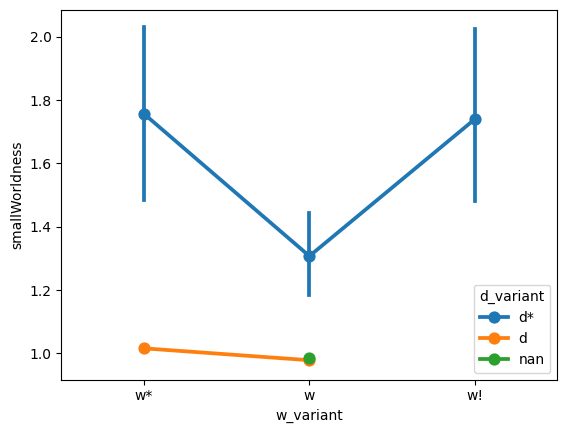

In [ ]:
sns.pointplot(x='w_variant', y='smallWorldness', hue='d_variant', data=final_df)

<Axes: xlabel='w_variant', ylabel='smallWorldness'>

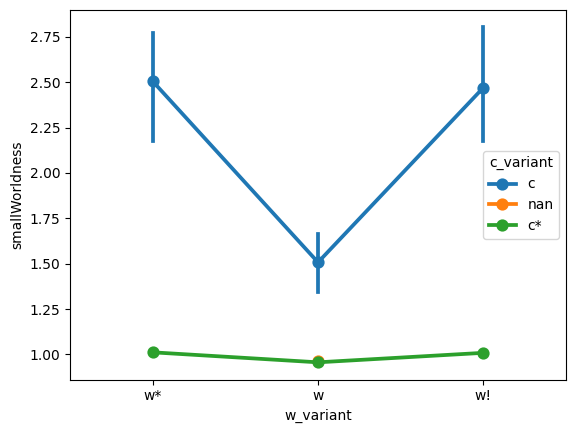

In [ ]:
sns.pointplot(x='w_variant', y='smallWorldness', hue='c_variant', data=final_df)

<Axes: xlabel='d_variant', ylabel='smallWorldness'>

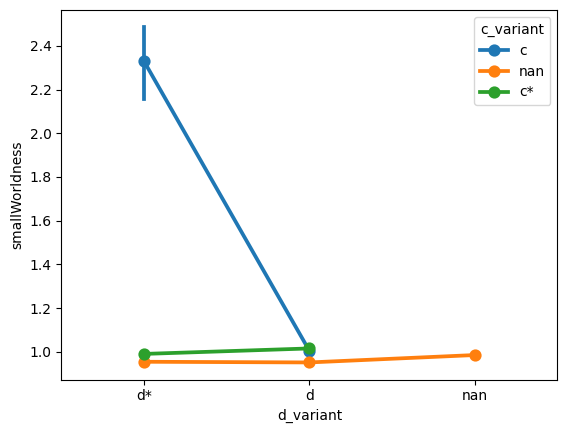

In [ ]:
sns.pointplot(x='d_variant', y='smallWorldness', hue='c_variant', data=final_df)

In [ ]:
print('###### W vs DC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'smallWorldness', 'w_variant', ['d_variant', 'c_variant'])
print('\n###### D vs WC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'smallWorldness', 'd_variant', ['w_variant', 'c_variant'])
print('\n###### C vs WD ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'smallWorldness', 'c_variant', ['w_variant', 'd_variant'])

###### W vs DC ######

=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=1.005 mean=1.005

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=1.013 mean=1.016

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=0.9524 mean=0.952

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=6.946, p=0.031
Group sizes & medians:
  w_variant=w          n=20   median=2.081 mean=2.01
  w_variant=w!         n=20   median=2.474 mean=2.47
  w_variant=w*         n=20   median=2.638 mean=2.505
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=120.0, p_raw=0.0315, p_adj=0.0946, sig=no, Median: w 2.081 < w! 2.474
  w vs w*: U=112.0, p_raw=0.0179, p_adj=0.0718, sig=no, Median: w 2.081 < w* 2.638
  w! vs w*: U=200.0, p_raw=1, p_adj=1, sig=no, Median: w! 2.474 < w* 2.638

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_variant: H=39.365, p=2.83e-09
Group sizes & medians:
  w_vari

In [ ]:
anova_results = rank_based_anova(final_df, 'assortivity')
anova_results

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(w_variant),7.268714e-10,2.0,2.716388e-13,1.000000e+00
C(d_variant),8.775729e+04,1.0,6.559148e+01,1.673872e-13
C(c_variant),-5.141186e-12,1.0,-3.842621e-15,1.000000e+00
C(w_variant):C(d_variant),2.745183e+05,2.0,1.025901e+02,6.319312e-29
C(w_variant):C(c_variant),1.189742e+04,2.0,4.446180e+00,3.661919e-02
C(d_variant):C(c_variant),4.125701e+03,1.0,3.083628e+00,8.109807e-02
C(w_variant):C(d_variant):C(c_variant),5.387754e+04,2.0,2.013455e+01,1.749808e-08
Residual,2.033665e+05,152.0,NaN,NaN


In [ ]:
print('###### W vs DC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'assortivity', 'w_variant', ['d_variant', 'c_variant'])
print('\n###### D vs WC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'assortivity', 'd_variant', ['w_variant', 'c_variant'])
print('\n###### C vs WD ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'assortivity', 'c_variant', ['w_variant', 'd_variant'])

###### W vs DC ######

=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=0.0514 mean=0.04849

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=-0.04652 mean=-0.04578

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=-0.005133 mean=-0.006794

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=39.439, p=2.73e-09
Group sizes & medians:
  w_variant=w          n=20   median=0.5596 mean=0.5223
  w_variant=w!         n=20   median=-0.1257 mean=-0.09867
  w_variant=w*         n=20   median=-0.1031 mean=-0.1082
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=400.0, p_raw=6.8e-08, p_adj=4.08e-07, sig=YES, Median: w 0.5596 > w! -0.1257
  w vs w*: U=400.0, p_raw=6.8e-08, p_adj=4.08e-07, sig=YES, Median: w 0.5596 > w* -0.1031
  w! vs w*: U=183.0, p_raw=0.655, p_adj=1, sig=no, Median: w! -0.1257 < w* -0.1031

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_varian

In [ ]:
anova_results = rank_based_anova(final_df, 'accuracy')
anova_results

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(w_variant),1.188061e-09,2.0,5.421746e-13,1.000000e+00
C(d_variant),6.492175e+04,1.0,5.925441e+01,1.637799e-12
C(c_variant),2.186113e-13,1.0,1.995277e-16,1.000000e+00
C(w_variant):C(d_variant),9.660259e+04,2.0,4.408484e+01,7.956684e-16
C(w_variant):C(c_variant),1.889513e+05,2.0,8.622839e+01,1.565826e-16
C(d_variant):C(c_variant),1.039155e+05,1.0,9.484425e+01,1.022267e-17
C(w_variant):C(d_variant):C(c_variant),5.488600e+04,2.0,2.504737e+01,3.962167e-10
Residual,1.665379e+05,152.0,NaN,NaN


<Axes: xlabel='w_variant', ylabel='accuracy'>

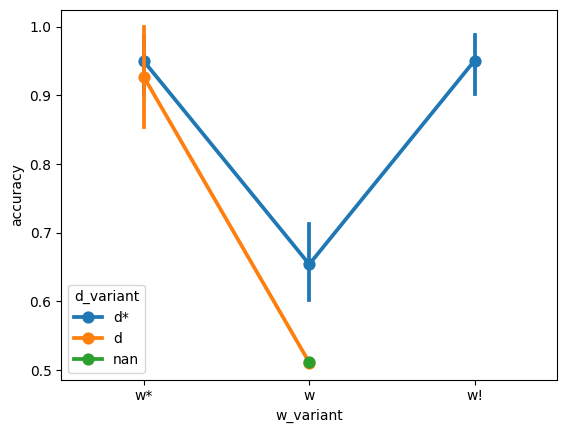

In [ ]:
sns.pointplot(x='w_variant', y='accuracy', hue='d_variant', data=final_df)

In [ ]:
print('###### W vs DC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'accuracy', 'w_variant', ['d_variant', 'c_variant'])
print('\n###### D vs WC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'accuracy', 'd_variant', ['w_variant', 'c_variant'])
print('\n###### C vs WD ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'accuracy', 'c_variant', ['w_variant', 'd_variant'])

###### W vs DC ######

=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=0.5115 mean=0.5109

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=1 mean=0.9267

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=0.5115 mean=0.5108

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=0.154, p=0.926
Group sizes & medians:
  w_variant=w          n=20   median=1 mean=0.9392
  w_variant=w!         n=20   median=1 mean=0.9505
  w_variant=w*         n=20   median=1 mean=0.9483

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_variant: H=44.113, p=2.64e-10
Group sizes & medians:
  w_variant=w          n=20   median=0.5115 mean=0.5112
  w_variant=w!         n=20   median=1 mean=0.9512
  w_variant=w*         n=20   median=1 mean=0.9512
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=14.0, p_raw=9.16e-08, p_adj=2.75e-07, sig=YES, Median: w 0.5115 < w! 1
  w vs w*: U=1

In [ ]:
anova_results = rank_based_anova(final_df, 'entropy')
anova_results

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(w_variant),6.158686e-10,2.0,2.381115e-13,1.000000e+00
C(d_variant),4.085699e+04,1.0,3.159285e+01,8.848270e-08
C(c_variant),3.912243e-09,1.0,3.025159e-12,9.999986e-01
C(w_variant):C(d_variant),2.750718e+04,2.0,1.063502e+01,4.754749e-05
C(w_variant):C(c_variant),8.056122e+03,2.0,3.114716e+00,7.959637e-02
C(d_variant):C(c_variant),7.622951e+04,1.0,5.894480e+01,1.834228e-12
C(w_variant):C(d_variant):C(c_variant),4.867245e+03,2.0,1.881809e+00,1.558456e-01
Residual,1.965718e+05,152.0,NaN,NaN


In [ ]:
print('###### W vs DC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'entropy', 'w_variant', ['d_variant', 'c_variant'])
print('\n###### D vs WC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'entropy', 'd_variant', ['w_variant', 'c_variant'])
print('\n###### C vs WD ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'entropy', 'c_variant', ['w_variant', 'd_variant'])

###### W vs DC ######

=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=0.05574 mean=0.2191

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=0.02684 mean=0.02667

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=0.04768 mean=0.8903

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=39.518, p=2.62e-09
Group sizes & medians:
  w_variant=w          n=20   median=4.443 mean=4.33
  w_variant=w!         n=20   median=0.9422 mean=0.8833
  w_variant=w*         n=20   median=0.6972 mean=0.793
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=400.0, p_raw=6.8e-08, p_adj=2.04e-07, sig=YES, Median: w 4.443 > w! 0.9422
  w vs w*: U=400.0, p_raw=6.8e-08, p_adj=2.04e-07, sig=YES, Median: w 4.443 > w* 0.6972
  w! vs w*: U=223.0, p_raw=0.543, p_adj=0.543, sig=no, Median: w! 0.9422 > w* 0.6972

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_variant: H=0.508, p=0.77

In [ ]:
anova_results = rank_based_anova(final_df, 'modularity')
anova_results

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(w_variant),-5.389167e-08,2.0,-2.582422e-11,1.000000e+00
C(d_variant),1.118571e+03,1.0,1.072011e+00,3.021361e-01
C(c_variant),8.596055e+06,1.0,8.238244e+03,2.675868e-134
C(w_variant):C(d_variant),4.570129e+04,2.0,2.189949e+01,4.390571e-09
C(w_variant):C(c_variant),1.445246e+05,2.0,6.925437e+01,4.622444e-14
C(d_variant):C(c_variant),2.856036e+05,1.0,2.737153e+02,8.160333e-36
C(w_variant):C(d_variant):C(c_variant),2.073897e+04,2.0,9.937853e+00,8.786402e-05
Residual,1.586018e+05,152.0,NaN,NaN


In [ ]:
print('###### W vs DC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'modularity', 'w_variant', ['d_variant', 'c_variant'])
print('\n###### D vs WC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'modularity', 'd_variant', ['w_variant', 'c_variant'])
print('\n###### C vs WD ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'modularity', 'c_variant', ['w_variant', 'd_variant'])

###### W vs DC ######

=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=0.09142 mean=0.09165

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=0.09839 mean=0.09891

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=0.08926 mean=0.08925

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=9.065, p=0.0108
Group sizes & medians:
  w_variant=w          n=20   median=0.5168 mean=0.4933
  w_variant=w!         n=20   median=0.4783 mean=0.4344
  w_variant=w*         n=20   median=0.4273 mean=0.4072
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=276.0, p_raw=0.0411, p_adj=0.0822, sig=no, Median: w 0.5168 > w! 0.4783
  w vs w*: U=309.0, p_raw=0.00334, p_adj=0.01, sig=YES, Median: w 0.5168 > w* 0.4273
  w! vs w*: U=228.0, p_raw=0.457, p_adj=0.457, sig=no, Median: w! 0.4783 > w* 0.4273

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_variant: H=2.126, p=0.345
G

In [ ]:
anova_results = rank_based_anova(final_df, 'loss')
anova_results

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(w_variant),1.052540e-09,2.0,3.792361e-12,1.000000e+00
C(d_variant),7.187431e+03,1.0,5.179345e+01,2.639359e-11
C(c_variant),-5.970550e-09,1.0,-4.302446e-11,1.000000e+00
C(w_variant):C(d_variant),9.041436e+04,2.0,3.257681e+02,1.095722e-55
C(w_variant):C(c_variant),2.005825e+05,2.0,7.227103e+02,1.229114e-59
C(d_variant):C(c_variant),1.082528e+04,1.0,7.800821e+01,2.330189e-15
C(w_variant):C(d_variant):C(c_variant),2.559961e+04,2.0,9.223684e+01,5.913283e-27
Residual,2.109320e+04,152.0,NaN,NaN


In [ ]:
print('###### W vs DC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'loss', 'w_variant', ['d_variant', 'c_variant'])
print('\n###### D vs WC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'loss', 'd_variant', ['w_variant', 'c_variant'])
print('\n###### C vs WD ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'loss', 'c_variant', ['w_variant', 'd_variant'])

###### W vs DC ######

=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=0.01778 mean=0.01778

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=0.9692 mean=0.97

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=0.6331 mean=0.633

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=37.945, p=5.76e-09
Group sizes & medians:
  w_variant=w          n=20   median=0.04654 mean=0.04565
  w_variant=w!         n=20   median=0.0007276 mean=0.004453
  w_variant=w*         n=20   median=0.001451 mean=0.006196
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=397.0, p_raw=1.06e-07, p_adj=6.39e-07, sig=YES, Median: w 0.04654 > w! 0.0007276
  w vs w*: U=395.0, p_raw=1.43e-07, p_adj=7.15e-07, sig=YES, Median: w 0.04654 > w* 0.001451
  w! vs w*: U=179.0, p_raw=0.579, p_adj=1, sig=no, Median: w! 0.0007276 < w* 0.001451

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_va

# The effect of number of neurons

In [ ]:
session, scan, field = 5, 3, 4

sign_constraint = False # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = False # Whether to use the precision matrix for the bio weights

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name_1 = f'/content/data/simu/{base}'
print(folder_name_1)

/content/data/simu/5_3_4_sttc-corr


In [ ]:
task1_folder_dir_neuron = f'{folder_name_1}/Task1/'
task1_folder_dir_neuron

'/content/data/simu/5_3_4_sttc-corr/Task1/'

In [ ]:
import pandas as pd

# List your metric files and their corresponding column names
metrics_dic = {
    "Accuracy_raw.csv": "accuracy",
    "Assortativity_raw.csv": "assortivity",
    "Modularity_raw.csv": "modularity",
    "Entropy_raw.csv": "entropy",
    "SmallWorldness_raw.csv": "smallWorldness",
    "Loss_raw.csv" : "loss",
    "Validation_Accuracy_raw.csv" : "validation_accuracy",
    "Validation_Loss_raw.csv" : "validation_loss"
}

dfs = []

for file, metric_name in metrics_dic.items():
    file_path = os.path.join(task1_folder_dir_neuron, file)
    # Read CSV (first column is simulation number / index)
    df = pd.read_csv(file_path, index_col=0)

    # Convert from wide format to long format
    df_long = df.reset_index().melt(
        id_vars=df.index.name,  # simulation number
        var_name="model_name",
        value_name=metric_name
    )

    dfs.append(df_long)

# Merge all metrics on simulation_number + model_name
from functools import reduce
final_df_neuron = reduce(lambda left, right: pd.merge(left, right, on=[df.index.name, "model_name"]), dfs)

# Rename index column to simulation_number
final_df_neuron.rename(columns={df.index.name: "simulation_number"}, inplace=True)

# Save to CSV
final_df_neuron.to_csv("combined_dataset_1.csv", index=False)

print(final_df_neuron.head())

   simulation_number model_name  accuracy  assortivity  modularity   entropy  \
0                  0      W*D*C  0.777930    -0.173498    0.602954  3.141714   
1                  1      W*D*C  0.755859     0.150889    0.628134  3.036219   
2                  2      W*D*C  1.000000    -0.127765    0.645759  2.697506   
3                  3      W*D*C  1.000000    -0.098826    0.615256  2.659157   
4                  4      W*D*C  1.000000     0.336267    0.580071  2.900176   

   smallWorldness      loss  validation_accuracy  validation_loss  
0        2.020549  0.917393             1.000000         0.651179  
1        1.521436  0.735113             0.738281         0.658513  
2        1.481063  0.046804             1.000000         0.043395  
3        1.688839  0.087450             1.000000         0.083395  
4        0.954364  0.088310             1.000000         0.080835  


In [ ]:
scaler = MinMaxScaler()
final_df_neuron["w_variant"] = final_df_neuron["model_name"].apply(classify_variant)
final_df_neuron["loss"] = scaler.fit_transform(final_df_neuron[["loss"]])
final_df_neuron['validation_loss'] = scaler.fit_transform(final_df_neuron[["validation_loss"]])

In [ ]:
final_df['neunum'] = 312
final_df_neuron['neunum'] = 70

In [ ]:
combined_df_neuron = pd.concat([final_df, final_df_neuron], ignore_index=True)

combined_df_neuron = combined_df_neuron.sort_values(["simulation_number", "model_name"]).reset_index(drop=True)

combined_df_neuron.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant,sign,matrix,d_variant,c_variant,neunum
0,0,W,0.617188,-0.016950,0.085761,5.657654,0.997841,0.330169,0.618359,0.302073,w,False,sttc,nan,nan,312
1,0,W,0.622266,-0.040578,0.199427,0.050396,0.775444,0.060112,0.621875,0.055012,w,NaN,NaN,NaN,NaN,70
2,0,W!D*C,1.000000,0.000551,0.470566,0.739893,2.225924,0.001798,1.000000,0.001418,w!,False,sttc,d*,c,312
3,0,W!D*C,1.000000,0.098730,0.625760,2.837234,1.539100,0.002830,1.000000,0.002748,w!,NaN,NaN,NaN,NaN,70
4,0,W!D*C*,1.000000,-0.045075,0.092286,1.102208,1.019185,0.399504,1.000000,0.369016,w!,False,sttc,d*,c*,312


In [ ]:
def is_number_of_neurons_significantly_different(df, metric):
  res = kruskal(
    df.query("neunum == 312")[metric],
    df.query("neunum == 70")[metric]
    )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:
for metric in metrics:
  print(f'{metric} : {is_number_of_neurons_significantly_different(combined_df_neuron, metric)}')

accuracy : (True, np.float64(0.0002846325706938227))
assortivity : (False, np.float64(0.16244733515480206))
entropy : (True, np.float64(1.5364618460622285e-18))
loss : (False, np.float64(0.8784295498227916))
modularity : (True, np.float64(4.422846121062874e-27))
smallWorldness : (True, np.float64(7.206914343134141e-25))
validation_accuracy : (True, np.float64(4.781658610682675e-06))
validation_loss : (False, np.float64(0.29470620796808666))


# other

In [ ]:
import itertools
import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

def simple_effects_w_within_dc(df, metric, alpha=0.05, correction='holm'):
    """
    For each (d_variant, c_variant) cell:
      1) omnibus test across all levels of w_variant (Kruskal–Wallis)
      2) if significant and w has >2 levels, do pairwise Mann–Whitney U with Holm correction
    Prints a tidy summary and returns a dict of results.
    """
    results = {}
    cells = df[['d_variant','c_variant']].drop_duplicates().itertuples(index=False, name=None)

    for d_val, c_val in cells:
        sub = df.query("d_variant == @d_val and c_variant == @c_val")[['w_variant', metric]].dropna()
        if sub.empty:
            continue

        # Split by w levels
        groups = {w: g[metric].astype(float).values for w, g in sub.groupby('w_variant')}
        levels = list(groups.keys())

        # Omnibus Kruskal–Wallis across w levels (nonparametric k-sample)
        if len(levels) >= 2:
            samples = [groups[w] for w in levels]
            H, p_omni = kruskal(*samples)
        else:
            H, p_omni = np.nan, np.nan  # only one w level; nothing to compare

        # Pairwise posthocs (only if >=3 levels and omnibus sig; if exactly 2 levels, we just do MWU)
        pairwise = []
        pairs = list(itertools.combinations(levels, 2))
        raw_ps = []
        stats_u = []
        extra = []

        if len(levels) == 2:
            w1, w2 = levels
            x, y = groups[w1], groups[w2]
            u, p = mannwhitneyu(x, y, alternative='two-sided')
            pairwise = [(w1, w2, u, p)]
            raw_ps = [p]
            stats_u = [u]
            extra = [{
                "w1": w1, "w2": w2,
                "median_w1": np.median(x), "median_w2": np.median(y),
                "n_w1": len(x), "n_w2": len(y),
                "P(X>Y)": u/(len(x)*len(y))
            }]
            reject, p_adj, _, _ = multipletests(raw_ps, method=correction, alpha=alpha)
        elif len(levels) > 2 and not np.isnan(p_omni) and p_omni < alpha:
            for (w1, w2) in pairs:
                x, y = groups[w1], groups[w2]
                u, p = mannwhitneyu(x, y, alternative='two-sided')
                pairwise.append((w1, w2, u, p))
                raw_ps.append(p)
                stats_u.append(u)
            reject, p_adj, _, _ = multipletests(raw_ps, method=correction, alpha=alpha)
            # enrich
            extra = []
            for (idx, (w1, w2, u, p)) in enumerate(pairwise):
                x, y = groups[w1], groups[w2]
                extra.append({
                    "w1": w1, "w2": w2,
                    "median_w1": np.median(x), "median_w2": np.median(y),
                    "n_w1": len(x), "n_w2": len(y),
                    "P(X>Y)": u/(len(x)*len(y))
                })
        else:
            reject, p_adj = [], []

        # Print a compact summary
        print(f"\n=== d={d_val}, c={c_val} ===")
        print(f"Kruskal–Wallis across w levels: H={H:.3f}  p={p_omni if np.isnan(p_omni) else f'{p_omni:.3g}'}")
        if len(levels) >= 2:
            print("Group sizes & medians:")
            for w in levels:
                arr = groups[w]
                print(f"  w={w:<10} n={len(arr):<4} median={np.median(arr):.4g} mean={np.mean(arr):.4g}")
        if pairwise:
            print("Pairwise Mann–Whitney (Holm-corrected):")
            for i, (w1, w2, u, p) in enumerate(pairwise):
                padj = p_adj[i]
                sig = "YES" if (len(reject)>i and reject[i]) else "no"
                ex = extra[i]
                direction = ">" if ex["median_w1"] > ex["median_w2"] else "<" if ex["median_w1"] < ex["median_w2"] else "="
                print(f"  {w1} vs {w2}: U={u:.1f}, p_raw={p:.3g}, p_adj={padj:.3g}, sig={sig}, "
                      f"Median: {w1} {ex['median_w1']:.4g} {direction} {w2} {ex['median_w2']:.4g}, "
                      f"P(X>Y)={ex['P(X>Y)']:.2f}")

        results[(d_val, c_val)] = {
            "kruskal_H": H, "kruskal_p": p_omni,
            "levels": levels,
            "pairwise": pairwise,
            "p_adj": p_adj if pairwise else None,
            "details": extra
        }

    print("\nDone.")
    return results

# Usage:
# simple_results = simple_effects_w_within_dc(final_df, 'smallWorldness', alpha=0.05, correction='holm')
import itertools
import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

def simple_effects_w_within_dc(df, metric, alpha=0.05, correction='holm'):
    """
    For each (d_variant, c_variant) cell:
      1) omnibus test across all levels of w_variant (Kruskal–Wallis)
      2) if significant and w has >2 levels, do pairwise Mann–Whitney U with Holm correction
    Prints a tidy summary and returns a dict of results.
    """
    results = {}
    cells = df[['d_variant','c_variant']].drop_duplicates().itertuples(index=False, name=None)

    for d_val, c_val in cells:
        sub = df.query("d_variant == @d_val and c_variant == @c_val")[['w_variant', metric]].dropna()
        if sub.empty:
            continue

        # Split by w levels
        groups = {w: g[metric].astype(float).values for w, g in sub.groupby('w_variant')}
        levels = list(groups.keys())

        # Omnibus Kruskal–Wallis across w levels (nonparametric k-sample)
        if len(levels) >= 2:
            samples = [groups[w] for w in levels]
            H, p_omni = kruskal(*samples)
        else:
            H, p_omni = np.nan, np.nan  # only one w level; nothing to compare

        # Pairwise posthocs (only if >=3 levels and omnibus sig; if exactly 2 levels, we just do MWU)
        pairwise = []
        pairs = list(itertools.combinations(levels, 2))
        raw_ps = []
        stats_u = []
        extra = []

        if len(levels) == 2:
            w1, w2 = levels
            x, y = groups[w1], groups[w2]
            u, p = mannwhitneyu(x, y, alternative='two-sided')
            pairwise = [(w1, w2, u, p)]
            raw_ps = [p]
            stats_u = [u]
            extra = [{
                "w1": w1, "w2": w2,
                "median_w1": np.median(x), "median_w2": np.median(y),
                "n_w1": len(x), "n_w2": len(y),
                "P(X>Y)": u/(len(x)*len(y))
            }]
            reject, p_adj, _, _ = multipletests(raw_ps, method=correction, alpha=alpha)
        elif len(levels) > 2 and not np.isnan(p_omni) and p_omni < alpha:
            for (w1, w2) in pairs:
                x, y = groups[w1], groups[w2]
                u, p = mannwhitneyu(x, y, alternative='two-sided')
                pairwise.append((w1, w2, u, p))
                raw_ps.append(p)
                stats_u.append(u)
            reject, p_adj, _, _ = multipletests(raw_ps, method=correction, alpha=alpha)
            # enrich
            extra = []
            for (idx, (w1, w2, u, p)) in enumerate(pairwise):
                x, y = groups[w1], groups[w2]
                extra.append({
                    "w1": w1, "w2": w2,
                    "median_w1": np.median(x), "median_w2": np.median(y),
                    "n_w1": len(x), "n_w2": len(y),
                    "P(X>Y)": u/(len(x)*len(y))
                })
        else:
            reject, p_adj = [], []

        # Print a compact summary
        print(f"\n=== d={d_val}, c={c_val} ===")
        print(f"Kruskal–Wallis across w levels: H={H:.3f}  p={p_omni if np.isnan(p_omni) else f'{p_omni:.3g}'}")
        if len(levels) >= 2:
            print("Group sizes & medians:")
            for w in levels:
                arr = groups[w]
                print(f"  w={w:<10} n={len(arr):<4} median={np.median(arr):.4g} mean={np.mean(arr):.4g}")
        if pairwise:
            print("Pairwise Mann–Whitney (Holm-corrected):")
            for i, (w1, w2, u, p) in enumerate(pairwise):
                padj = p_adj[i]
                sig = "YES" if (len(reject)>i and reject[i]) else "no"
                ex = extra[i]
                direction = ">" if ex["median_w1"] > ex["median_w2"] else "<" if ex["median_w1"] < ex["median_w2"] else "="
                print(f"  {w1} vs {w2}: U={u:.1f}, p_raw={p:.3g}, p_adj={padj:.3g}, sig={sig}, "
                      f"Median: {w1} {ex['median_w1']:.4g} {direction} {w2} {ex['median_w2']:.4g}, "
                      f"P(X>Y)={ex['P(X>Y)']:.2f}")

        results[(d_val, c_val)] = {
            "kruskal_H": H, "kruskal_p": p_omni,
            "levels": levels,
            "pairwise": pairwise,
            "p_adj": p_adj if pairwise else None,
            "details": extra
        }

    print("\nDone.")
    return results

# Usage:
simple_results = simple_effects_w_within_dc(final_df, 'accuracy', alpha=0.05, correction='holm')



=== d=d*, c=c ===
Kruskal–Wallis across w levels: H=38.227  p=5e-09
Group sizes & medians:
  w=w          n=20   median=0.628 mean=0.6282
  w=w!         n=20   median=1 mean=0.9496
  w=w*         n=20   median=1 mean=0.9168
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=26.0, p_raw=1.23e-06, p_adj=2.46e-06, sig=YES, Median: w 0.628 < w! 1, P(X>Y)=0.07
  w vs w*: U=3.0, p_raw=6.36e-08, p_adj=1.91e-07, sig=YES, Median: w 0.628 < w* 1, P(X>Y)=0.01
  w! vs w*: U=226.0, p_raw=0.381, p_adj=0.381, sig=no, Median: w! 1 = w* 1, P(X>Y)=0.56

=== d=d, c=c ===
Kruskal–Wallis across w levels: H=nan  p=nan

=== d=d*, c=nan ===
Kruskal–Wallis across w levels: H=nan  p=nan

=== d=d, c=nan ===
Kruskal–Wallis across w levels: H=nan  p=nan

=== d=nan, c=nan ===
Kruskal–Wallis across w levels: H=nan  p=nan

=== d=d*, c=c* ===
Kruskal–Wallis across w levels: H=24.205  p=5.55e-06
Group sizes & medians:
  w=w          n=20   median=0.6302 mean=0.7575
  w=w!         n=20   median=1 mean=0.9631
  w=w*  

In [ ]:
import itertools
import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

def _vargha_delaney_A12(x, y):
    """Vargha–Delaney A12 = P(X>Y) + 0.5*P(X==Y). For MWU without ties, A12 ~ U/(n1*n2)."""
    x = np.asarray(x); y = np.asarray(y)
    n1, n2 = len(x), len(y)
    # Use ranks approach to handle ties properly
    allvals = np.concatenate([x, y])
    ranks = pd.Series(allvals).rank(method='average').to_numpy()
    rx = ranks[:n1].sum()
    # U for group X:
    U = rx - n1*(n1+1)/2
    A12 = U / (n1*n2)
    # With ties, A12 computed this way approximates P(X>Y); to incorporate ties:
    # A12_tie = A12 + 0.5*(1 - A12 - P(Y>X)) but we stick to standard MW mapping.
    return float(A12)

def _cliffs_delta(x, y):
    """Cliff's delta in O(n log n) via ranks (approx)."""
    x = np.asarray(x); y = np.asarray(y)
    n1, n2 = len(x), len(y)
    # brute force is O(n1*n2); for practical n this is fine
    greater = 0; less = 0
    for xi in x:
        greater += np.sum(xi > y)
        less    += np.sum(xi < y)
    delta = (greater - less) / (n1 * n2)
    return float(delta)

def simple_effects_w_within_dc_df(df, metric, alpha=0.05, correction='holm', mw_method='auto'):
    """
    Stratified simple-effects of w within each (d_variant, c_variant) cell.

    Returns a tidy DataFrame with:
      - one row for each cell's Kruskal–Wallis omnibus (k-sample)
      - one row per pairwise w comparison with Holm-adjusted p-values
    `correction` is applied GLOBALLY over all pairwise rows across all cells.
    """
    records_omni = []
    records_pairs = []

    # stable ordering of cells for reproducibility
    cells = (
        df[['d_variant','c_variant']]
        .dropna()
        .drop_duplicates()
        .sort_values(['d_variant','c_variant'])
        .itertuples(index=False, name=None)
    )

    # First pass: compute all raw results and collect raw p-values for global correction
    for d_val, c_val in cells:
        sub = df.query("d_variant == @d_val and c_variant == @c_val")[['w_variant', metric]].dropna()
        if sub.empty:
            continue

        # groups by w (sorted for stable printing)
        groups = {w: g[metric].astype(float).to_numpy()
                  for w, g in sub.groupby('w_variant')}
        levels = sorted(groups.keys(), key=lambda z: str(z))

        # Omnibus
        if len(levels) >= 2:
            samples = [groups[w] for w in levels]
            H, p_omni = kruskal(*samples)
        else:
            H, p_omni = np.nan, np.nan

        n_by_w = {w: len(groups[w]) for w in levels}
        med_by_w = {w: float(np.median(groups[w])) for w in levels}
        mean_by_w = {w: float(np.mean(groups[w])) for w in levels}

        records_omni.append({
            'd_variant': d_val,
            'c_variant': c_val,
            'metric': metric,
            'w_levels': tuple(levels),
            'kruskal_H': H,
            'kruskal_p': p_omni,
            'n_by_w': n_by_w,
            'median_by_w': med_by_w,
            'mean_by_w': mean_by_w
        })

        # Pairwise tests:
        pairs = list(itertools.combinations(levels, 2))
        # Strategy:
        # - if there are exactly 2 levels, always do a pairwise MWU (even if omnibus NaN)
        # - if >2 levels, only do pairwise if omnibus < alpha (common practice)
        do_pairs = False
        if len(levels) == 2:
            do_pairs = True
        elif len(levels) > 2 and (not np.isnan(p_omni)) and (p_omni < alpha):
            do_pairs = True

        if do_pairs:
            for w1, w2 in pairs:
                x, y = groups[w1], groups[w2]
                # Two-sided MWU. Use exact when small n and few ties (SciPy >=1.7 supports method kw)
                u, p_raw = mannwhitneyu(x, y, alternative='two-sided', method=mw_method)
                A12 = _vargha_delaney_A12(x, y)
                delta = _cliffs_delta(x, y)
                rec = {
                    'd_variant': d_val,
                    'c_variant': c_val,
                    'metric': metric,
                    'w1': w1, 'w2': w2,
                    'n_w1': len(x), 'n_w2': len(y),
                    'median_w1': float(np.median(x)),
                    'median_w2': float(np.median(y)),
                    'mean_w1': float(np.mean(x)),
                    'mean_w2': float(np.mean(y)),
                    'U': float(u),
                    'p_raw': float(p_raw),
                    'A12': A12,            # ≈ P(X>Y)
                    'cliffs_delta': delta  # effect size in [-1,1]
                }
                records_pairs.append(rec)

    # Global multiplicity correction over all pairwise rows
    if len(records_pairs) > 0:
        pvals = [r['p_raw'] for r in records_pairs]
        reject, p_adj, _, _ = multipletests(pvals, method=correction, alpha=alpha)
        for i, r in enumerate(records_pairs):
            r['p_adj'] = float(p_adj[i])
            r['significant'] = bool(reject[i])
    else:
        p_adj = []

    df_omni = pd.DataFrame.from_records(records_omni)
    df_pairs = pd.DataFrame.from_records(records_pairs)

    # Pretty print (optional)
    for _, row in df_omni.iterrows():
        d_val, c_val = row['d_variant'], row['c_variant']
        H, p = row['kruskal_H'], row['kruskal_p']
        print(f"\n=== d={d_val}, c={c_val} ===")
        if len(row['w_levels']) >= 2:
            ptxt = "nan" if pd.isna(p) else f"{p:.3g}"
            print(f"Kruskal–Wallis across w: H={H:.3f}, p={ptxt}")
            print("Group sizes & medians:")
            for w in row['w_levels']:
                print(f"  w={w:<10} n={row['n_by_w'][w]:<4} median={row['median_by_w'][w]:.6g} mean={row['mean_by_w'][w]:.6g}")
        else:
            # There is only one w_variant in this (d, c)
            w = levels[0]
            arr = groups[w]
            print(f"Only one w level present: w={w}")
            print(f"  n={len(arr)}  median={np.median(arr):.4g}  mean={np.mean(arr):.4g}")
            # results[(d_val, c_val)] = {
            #     "kruskal_H": np.nan, "kruskal_p": np.nan,
            #     "levels": levels,
            #     "pairwise": [],
            #     "p_adj": None,
            #     "details": [{
            #         "w1": w,
            #         "n_w1": len(arr),
            #         "median_w1": np.median(arr),
            #         "mean_w1": np.mean(arr)
            #     }]
            # }
            continue
        # Show pairwise for this cell (if any)
        if not df_pairs.empty:
            sub_pairs = df_pairs.query("d_variant == @d_val and c_variant == @c_val")
            if not sub_pairs.empty:
                print("Pairwise Mann–Whitney (global Holm-corrected):")
                for _, r2 in sub_pairs.iterrows():
                    direction = ">" if r2['median_w1'] > r2['median_w2'] else "<" if r2['median_w1'] < r2['median_w2'] else "="
                    padj_txt = "nan" if pd.isna(r2['p_adj']) else f"{r2['p_adj']:.3g}"
                    print(f"  {r2['w1']} vs {r2['w2']}: U={r2['U']:.1f}, p_raw={r2['p_raw']:.3g}, p_adj={padj_txt}, "
                          f"sig={'YES' if r2.get('significant', False) else 'no'}, "
                          f"Median: {r2['w1']} {r2['median_w1']:.6g} {direction} {r2['w2']} {r2['median_w2']:.6g}, "
                          f"A12={r2['A12']:.3f}, Cliffδ={r2['cliffs_delta']:.3f}")

    print("\nDone.")
    return df_omni, df_pairs

# Example usage:
df_omni, df_pairs = simple_effects_w_within_dc_df(final_df, 'accuracy', alpha=0.05, correction='holm', mw_method='auto')
# Now you can sort/filter df_pairs, make plots, etc.



=== d=d, c=c ===
Only one w level present: w=w
  n=20  median=0.6245  mean=0.6248

=== d=d, c=c* ===
Only one w level present: w=w
  n=20  median=0.6245  mean=0.6248

=== d=d, c=nan ===
Only one w level present: w=w
  n=20  median=0.6245  mean=0.6248

=== d=d*, c=c ===
Kruskal–Wallis across w: H=38.227, p=5e-09
Group sizes & medians:
  w=w          n=20   median=0.628027 mean=0.628223
  w=w!         n=20   median=1 mean=0.949609
  w=w*         n=20   median=1 mean=0.916777
Pairwise Mann–Whitney (global Holm-corrected):
  w vs w!: U=26.0, p_raw=1.23e-06, p_adj=6.16e-06, sig=YES, Median: w 0.628027 < w! 1, A12=0.065, Cliffδ=-0.870
  w vs w*: U=3.0, p_raw=6.36e-08, p_adj=3.81e-07, sig=YES, Median: w 0.628027 < w* 1, A12=0.007, Cliffδ=-0.985
  w! vs w*: U=226.0, p_raw=0.381, p_adj=0.761, sig=no, Median: w! 1 = w* 1, A12=0.565, Cliffδ=0.130

=== d=d*, c=c* ===
Kruskal–Wallis across w: H=24.205, p=5.55e-06
Group sizes & medians:
  w=w          n=20   median=0.630176 mean=0.75751
  w=w!     